In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
train_df = pd.read_csv('arxiv_dataset/train.csv')
test_df = pd.read_csv('arxiv_dataset/test.csv')

In [3]:
train_df.head()

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,paper_id,title,primary_category,authors,first_author,abstract,days_since_submission,recency_score
0,0,0,0,cs-9308101v1,Dynamic Backtracking,cs.AI,M. L. Ginsberg,M. L. Ginsberg,Because of their occasional need to return to ...,12006,0.05
1,1,1,1,cs-9308102v1,A Market-Oriented Programming Environment and ...,cs.AI,M. P. Wellman,M. P. Wellman,Market price systems constitute a well-underst...,12006,0.05
2,2,2,2,cs-9309101v1,An Empirical Analysis of Search in GSAT,cs.AI,I. P. Gent; T. Walsh,I. P. Gent,We describe an extensive study of search in GS...,11975,0.05
3,3,3,3,cs-9311101v1,The Difficulties of Learning Logic Programs wi...,cs.AI,F. Bergadano; D. Gunetti; U. Trinchero,F. Bergadano,As real logic programmers normally use cut (!)...,11914,0.05
4,4,4,4,cs-9311102v1,Software Agents: Completing Patterns and Const...,cs.AI,J. C. Schlimmer; L. A. Hermens,J. C. Schlimmer,To support the goal of allowing users to recor...,11914,0.05


In [4]:
test_df.head()

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,paper_id,title,primary_category,authors,first_author,abstract,days_since_submission,recency_score
0,0,0,0,2604.26951v1,Turning the TIDE: Cross-Architecture Distillat...,cs.CL,Gongbo Zhang; Wen Wang; Ye Tian; Li Yuan,Gongbo Zhang,Diffusion large language models (dLLMs) offer ...,47,0.711484
1,1,1,1,2604.26231v1,ProMax: Exploring the Potential of LLM-derived...,cs.IR,Yi Zhang; Yiwen Zhang; Kai Zheng; Tong Chen; H...,Yi Zhang,The remarkable text understanding and generati...,47,0.711484
2,2,2,2,2604.26567v1,AirZoo: A Unified Large-Scale Dataset for Grou...,cs.CV,Xiaoya Cheng; Rouwan Wu; Xinyi Liu; Zeyu Cui; ...,Xiaoya Cheng,Despite the rapid progress in data-driven 3D v...,47,0.711484
3,3,3,3,2604.26565v1,"DenseStep2M: A Scalable, Training-Free Pipelin...",cs.CV,Mingji Ge; Qirui Chen; Zeqian Li; Weidi Xie,Mingji Ge,Long-term video understanding requires interpr...,47,0.711484
4,4,4,4,2604.26520v1,3D-LENS: A 3D Lifting-based Elevated Novel-vie...,cs.CV,William Grolleau; Astrid Sabourin; Guillaume L...,William Grolleau,Aerial-Ground Re-Identification (AG-ReID) is c...,47,0.711484


In [5]:
alpha=0.05
half_life = 90
age_test = test_df['days_since_submission'].values
age_train = train_df['days_since_submission'].values
test_df['recency_score'] = ((1-alpha)*(2**(-age_test/half_life))+alpha).astype(np.float32)
train_df['recency_score'] = ((1-alpha)*(2**(-age_train/half_life))+alpha).astype(np.float32)


In [ ]:
train_df.to_csv('arxiv_dataset/train.csv')
test_df.to_csv('arxiv/dataset/test.csv')

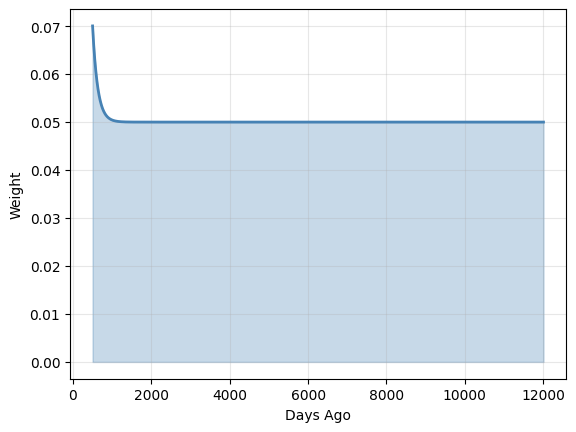

In [32]:
draw = train_df.sort_values(by = 'days_since_submission')
plt.plot(draw['days_since_submission'].values, draw['recency_score'].values, linewidth=2, color='steelblue')
plt.fill_between(draw['days_since_submission'].values, draw['recency_score'].values, alpha=0.3, color='steelblue')
plt.xlabel('Days Ago')
plt.ylabel('Weight')
plt.grid(True, alpha=0.3)


In [ ]:
# !pip install nltk
# !pip install scikit-learn

In [5]:
def create_data_input(df, columns):
    result=[]
    for id, row in df.iterrows():
        tmp_text = [col+' : '+str(row[col]) for col in columns]
        text = ' || '.join(tmp_text)
        result.append(text)
    return result

In [8]:
tfidf_input = create_data_input(train_df, columns = ['title', 'abstract', 'primary_category'])
print(len(tfidf_input))

136238


In [9]:
print(tfidf_input[2])

title : An Empirical Analysis of Search in GSAT || abstract : We describe an extensive study of search in GSAT, an approximation procedure
for propositional satisfiability. GSAT performs greedy hill-climbing on the
number of satisfied clauses in a truth assignment. Our experiments provide a
more complete picture of GSAT's search than previous accounts. We describe in
detail the two phases of search: rapid hill-climbing followed by a long plateau
search. We demonstrate that when applied to randomly generated 3SAT problems,
there is a very simple scaling with problem size for both the mean number of
satisfied clauses and the mean branching rate. Our results allow us to make
detailed numerical conjectures about the length of the hill-climbing phase, the
average gradient of this phase, and to conjecture that both the average score
and average branching rate decay exponentially during plateau search. We end by
showing how these results can be used to direct future theoretical analysis.
This

In [10]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

class TextPreprocessor:
    def __init__(self):
        self.stop_words = set(stopwords.words('english'))
        self.lemmatizer = WordNetLemmatizer()
        self.vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,2), max_df=0.9, min_df = 10)

    def preprocess(self, text):
        # Lowercase
        text = text.lower()
        # Remove punctuation and numbers
        text = re.sub(r'[^a-z\s]', '', text)
        # Tokenize
        tokens = word_tokenize(text)
        # Remove stop words and lemmatize
        tokens = [self.lemmatizer.lemmatize(word) for word in tokens if word not in self.stop_words]
        return ' '.join(tokens)

    def fit_transform(self, texts):
        preprocessed_texts = [self.preprocess(text) for text in texts]
        return self.vectorizer.fit_transform(preprocessed_texts)

    def transform(self, texts):
        preprocessed_texts = [self.preprocess(text) for text in texts]
        return self.vectorizer.transform(preprocessed_texts)
    
preprocessor = TextPreprocessor()
tfidf_matrix = preprocessor.fit_transform(tfidf_input)


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\TTD\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\TTD\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\TTD\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\TTD\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\TTD\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [11]:
import scipy.sparse
import joblib

scipy.sparse.save_npz('tfidf_matrix.npz', tfidf_matrix)
joblib.dump(preprocessor, 'text_preprocessor.pkl')

['text_preprocessor.pkl']

In [12]:
tfidf_matrix.shape

(136238, 10000)

In [13]:
from sklearn.metrics.pairwise import cosine_similarity as cossim
pair = (0, 0)
max = -1.0
j=3
for i in range(0, 7700):
    if max < cossim(tfidf_matrix[j], tfidf_matrix[i])[0][0] and i!=j:
        max = cossim(tfidf_matrix[j], tfidf_matrix[i])[0][0]
        pair = (j, i)
print(max, pair)
    

0.40053329608304383 (3, 2369)


In [15]:
print(cossim(tfidf_matrix[7], tfidf_matrix[2]))

[[0.02973158]]


In [18]:
print(tfidf_matrix[3])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 82 stored elements and shape (1, 10000)>
  Coords	Values
  (0, 5856)	0.04671756224634284
  (0, 5271)	0.022857140924526443
  (0, 6976)	0.02842741629690158
  (0, 6395)	0.024548106780354673
  (0, 8410)	0.08292316411752658
  (0, 2454)	0.12382864576669408
  (0, 8959)	0.038327988949590434
  (0, 612)	0.02637745645813679
  (0, 1954)	0.04394517941306753
  (0, 6915)	0.04394517941306753
  (0, 8830)	0.034975094764399056
  (0, 2706)	0.044441704807605946
  (0, 522)	0.03664419243242879
  (0, 7017)	0.0555948222168862
  (0, 1369)	0.18701065904369607
  (0, 5079)	0.043794418495072776
  (0, 4766)	0.11870353342774045
  (0, 4977)	0.26908899099063976
  (0, 7051)	0.3372658779815833
  (0, 1997)	0.6292263190272325
  (0, 7341)	0.047592902341907654
  (0, 6078)	0.09341703942364171
  (0, 9572)	0.03543650781773353
  (0, 7)	0.05070003784700772
  (0, 2147)	0.06365255350728342
  :	:
  (0, 5076)	0.06022492879756319
  (0, 8167)	0.07760973588306128
  (0, 232)	0

In [22]:
print(preprocessor.vectorizer.get_feature_names_out()[400::700])

['algorithm developed' 'boosting' 'controllable' 'discrepancy' 'extractor'
 'high cost' 'kind' 'method directly' 'new type' 'plot' 'recent year'
 'series classification' 'switching' 'unified']
